# 1. Loading the Datasets

In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
sample_sub = pd.read_csv("/kaggle/input/datasets/ikshugupta/nlp-projet/Sample.csv")
test = pd.read_csv("/kaggle/input/datasets/ikshugupta/nlp-projet/test (1).csv")
train = pd.read_csv("/kaggle/input/datasets/ikshugupta/nlp-projet/train (1).csv")

# 2. Exploratory Data Analysis (EDA)

## 2.1 - Basic Information

In [3]:
print("Shape of train:", train.shape)
print("Shape of test:", test.shape)
print("Shape of sample_sub:", sample_sub.shape)

print("\nColumn names and data types:")
print(train.dtypes)

print("\nFirst 5 rows:")
train.head()

Shape of train: (198000, 15)
Shape of test: (102000, 14)
Shape of sample_sub: (102000, 2)

Column names and data types:
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

First 5 rows:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## 2.2 - Target Variable Analysis

Label distribution (count):
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Label distribution (percentage):
label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


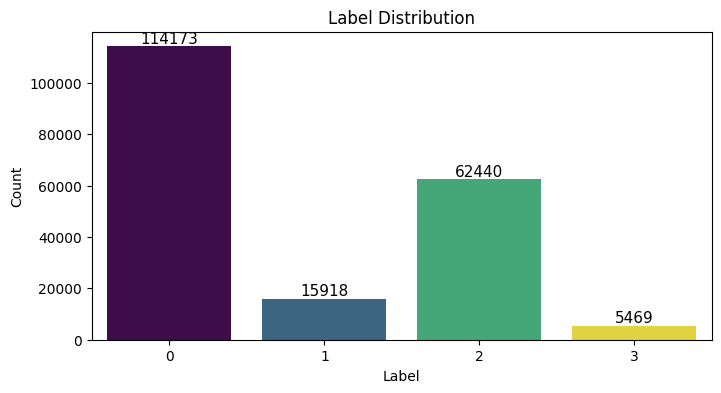

In [4]:
print("Label distribution (count):")
print(train['label'].value_counts())

print("\nLabel distribution (percentage):")
print(train['label'].value_counts(normalize=True)*100)

# Plot
plt.figure(figsize=(8,4))
ax = sns.countplot(x='label', data=train, hue='label', palette='viridis', legend=False)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

Insight:
- Label 0 is the most common (57%) → model will be biased towards this
- Label 3 is the rarest (2.7%)     → model will struggle to predict this
- This is called CLASS IMBALANCE

## 2.3 - Missing Values Analysis

Missing values in train:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64

Missing percentage:
race        73.45
religion    73.45
gender      73.45
comment      0.00
dtype: float64

Missing values in test:
race        75269
religion    75269
gender      75269
dtype: int64


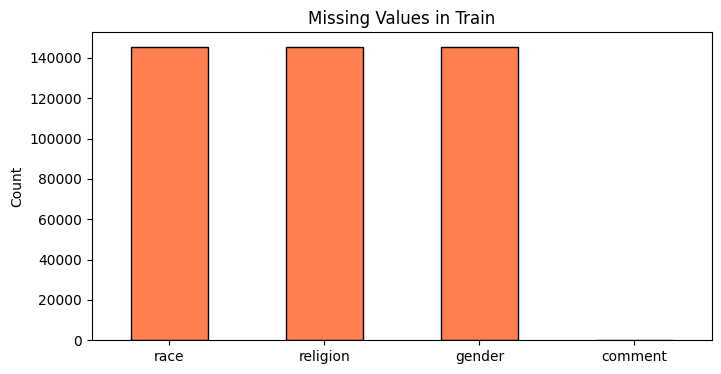

In [5]:
print("Missing values in train:")
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0]
print(missing_train)
print("\nMissing percentage:")
print((missing_train/len(train)*100).round(2))

print("\nMissing values in test:")
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0]
print(missing_test)

# Plot
plt.figure(figsize=(8,4))
missing_train.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values in Train')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 2.4 - Numerical Features Analysis

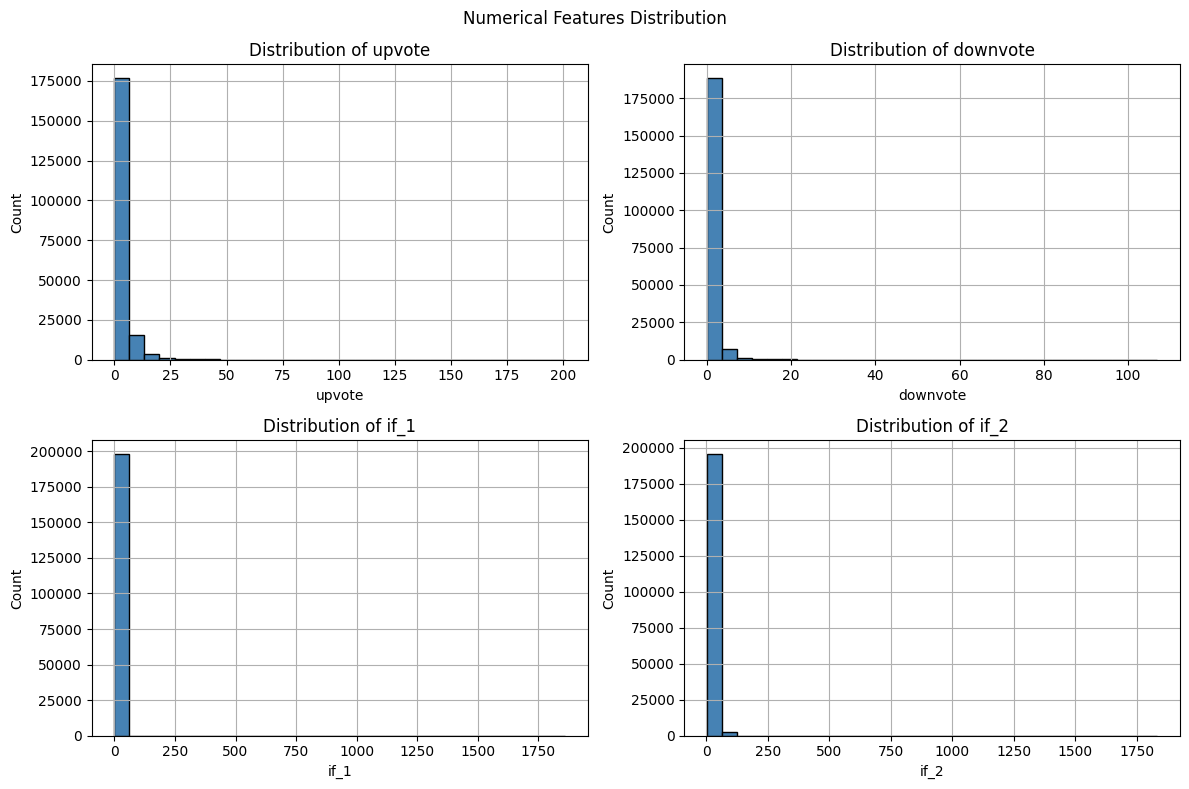

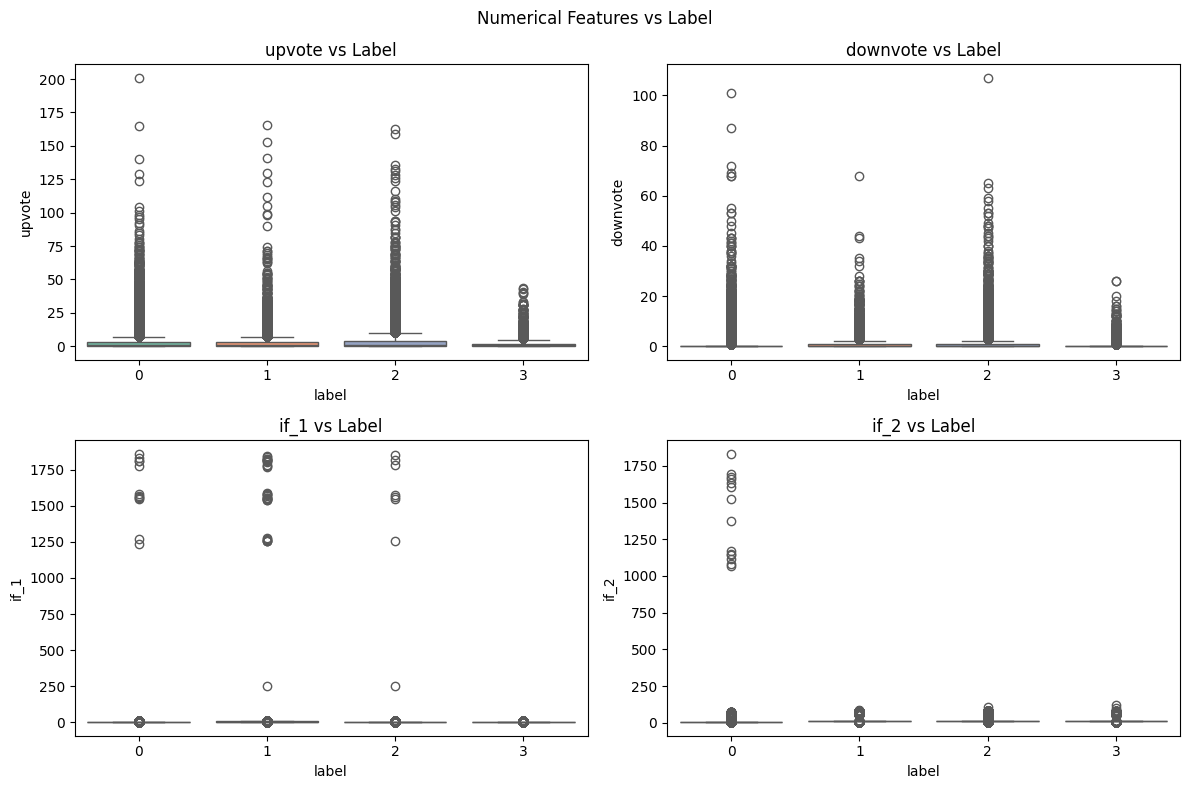

Summary statistics of numerical features:
              upvote       downvote           if_1           if_2
count  198000.000000  198000.000000  198000.000000  198000.000000
mean        2.607975       0.666394       1.906152       7.956212
std         5.054763       2.044335      25.635752      14.839464
min         0.000000       0.000000       0.000000       3.000000
25%         0.000000       0.000000       0.000000       4.000000
50%         1.000000       0.000000       0.000000       6.000000
75%         3.000000       1.000000       4.000000      10.000000
max       201.000000     107.000000    1860.000000    1833.000000


In [6]:
num_cols = ['upvote', 'downvote', 'if_1', 'if_2']

# Distribution of each numerical feature
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for i, col in enumerate(num_cols):
    ax = axes[i//2][i%2]
    train[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Numerical Features Distribution')
plt.tight_layout()
plt.show()

# Relationship with label
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for i, col in enumerate(num_cols):
    ax = axes[i//2][i%2]
    sns.boxplot(x='label', y=col, data=train, ax=ax, 
                hue='label', palette='Set2', legend=False)
    ax.set_title(f'{col} vs Label')
plt.suptitle('Numerical Features vs Label')
plt.tight_layout()
plt.show()

# Summary statistics
print("Summary statistics of numerical features:")
print(train[num_cols].describe())

## 2.5 - Categorical Features Analysis

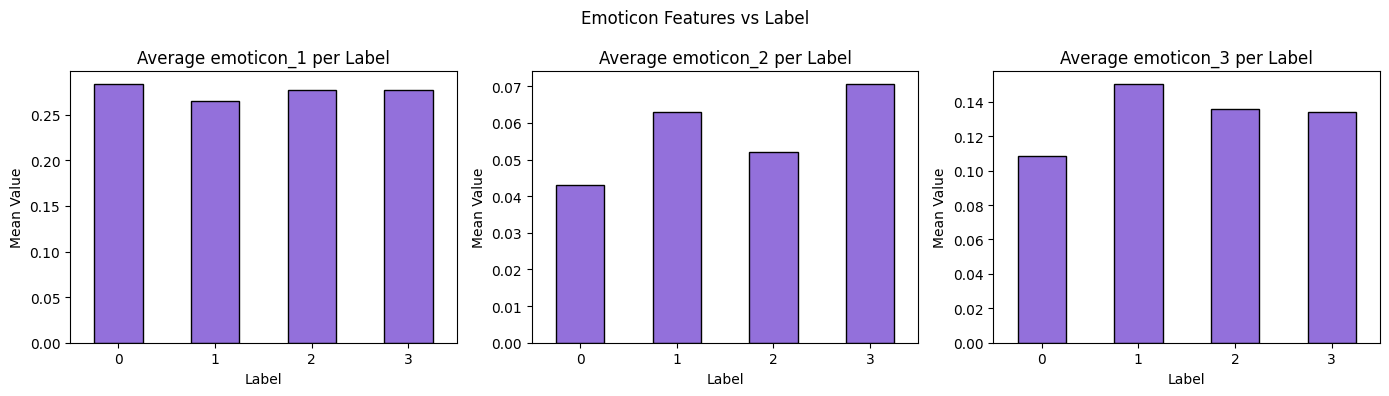

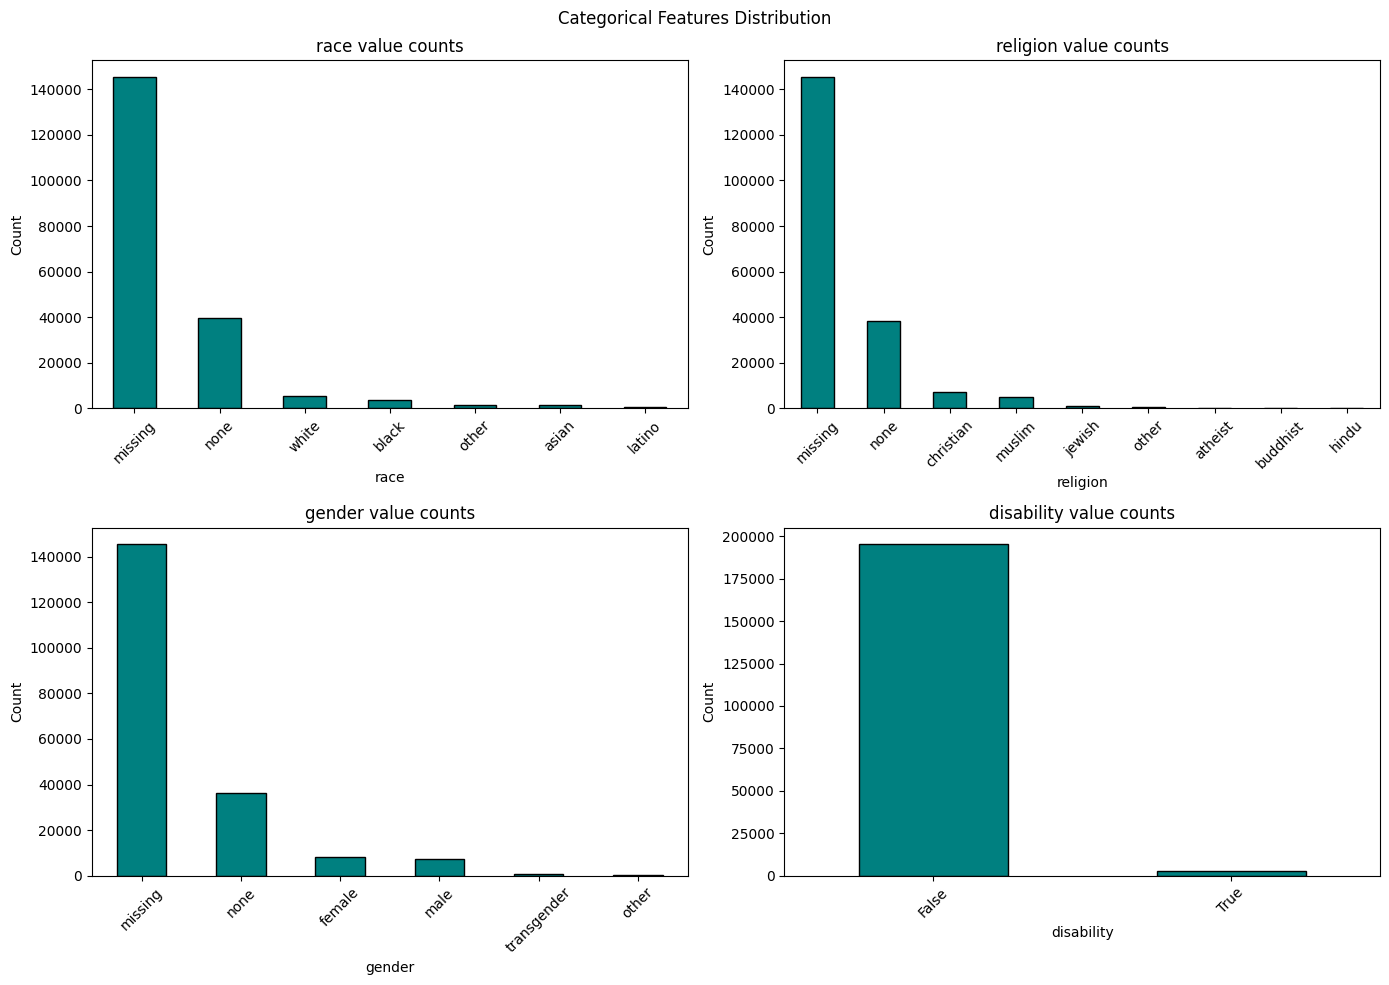

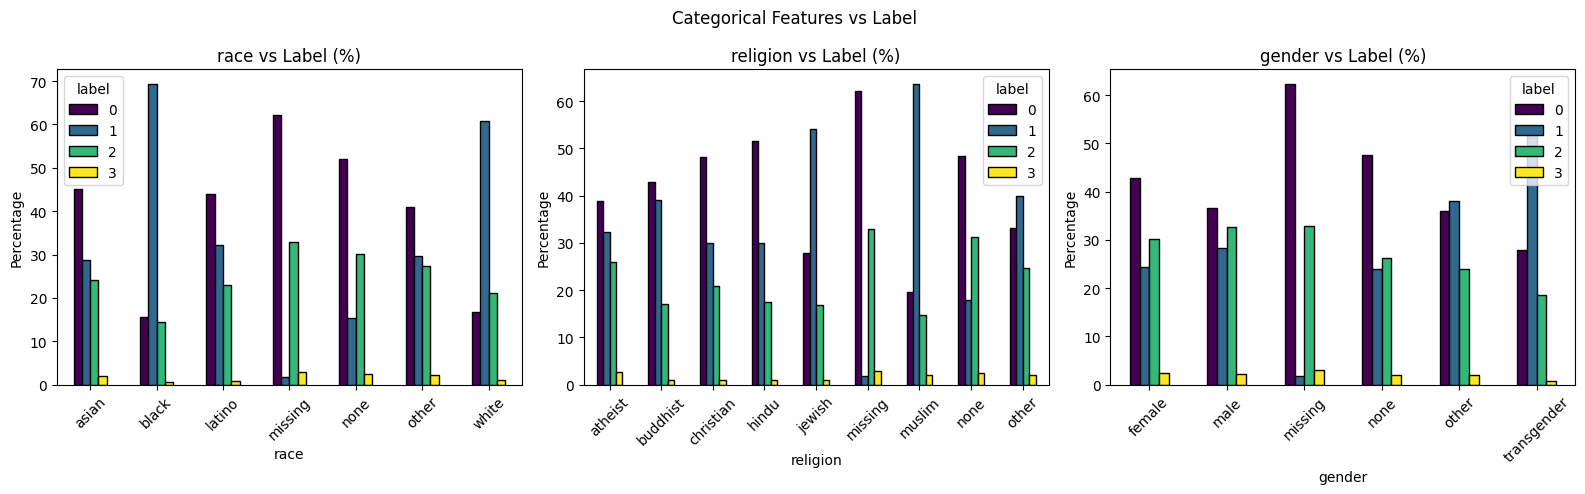

In [7]:
# Emoticons
emoticon_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3']
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for i, col in enumerate(emoticon_cols):
    train.groupby('label')[col].mean().plot(
        kind='bar', ax=axes[i], color='mediumpurple', edgecolor='black')
    axes[i].set_title(f'Average {col} per Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('Mean Value')
    axes[i].tick_params(axis='x', rotation=0)
plt.suptitle('Emoticon Features vs Label')
plt.tight_layout()
plt.show()

# Race, Religion, Gender
cat_cols = ['race', 'religion', 'gender', 'disability']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for i, col in enumerate(cat_cols):
    ax = axes[i//2][i%2]
    train[col].fillna('missing').value_counts().plot(
        kind='bar', ax=ax, color='teal', edgecolor='black')
    ax.set_title(f'{col} value counts')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Features Distribution')
plt.tight_layout()
plt.show()

# How race/religion/gender relate to label
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for i, col in enumerate(['race', 'religion', 'gender']):
    crosstab = pd.crosstab(train[col].fillna('missing'), train['label'], normalize='index')*100
    crosstab.plot(kind='bar', ax=axes[i], colormap='viridis', edgecolor='black')
    axes[i].set_title(f'{col} vs Label (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='label')
plt.suptitle('Categorical Features vs Label')
plt.tight_layout()
plt.show()

## 2.6 - Text Feature Analysis

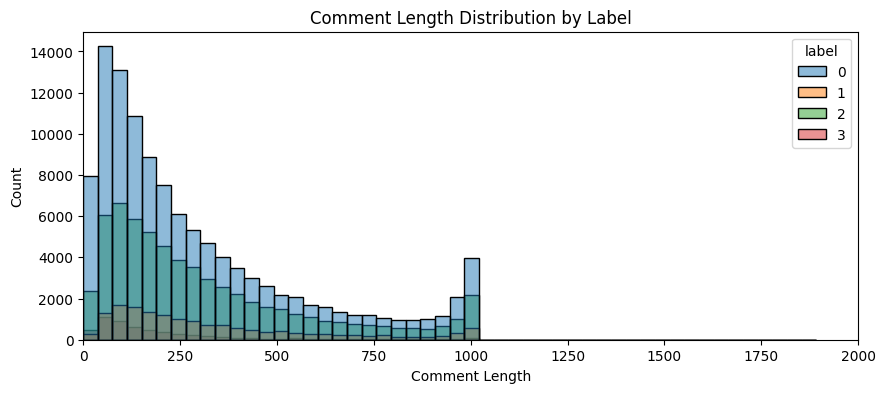

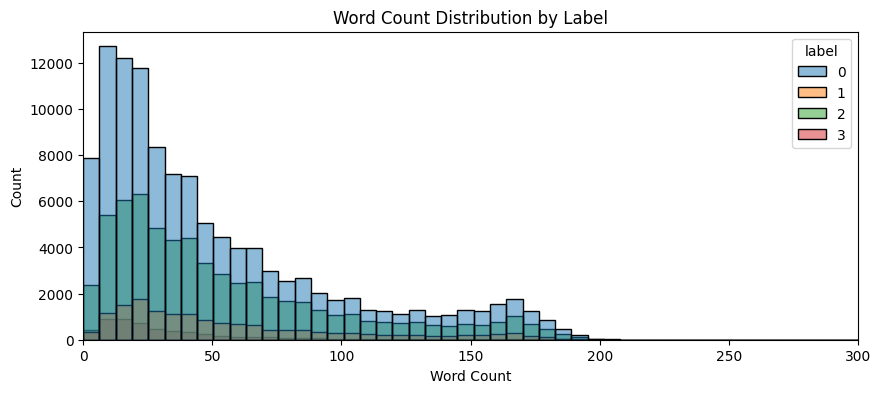

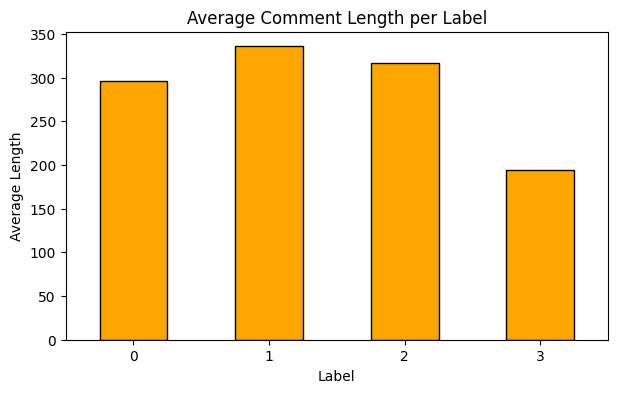

Average comment length per label:
label
0    295.90
1    335.71
2    316.89
3    194.17
Name: comment_length, dtype: float64

Average word count per label:
label
0    51.19
1    57.23
2    54.90
3    34.98
Name: word_count, dtype: float64


In [8]:
# Add text features
train['comment'] = train['comment'].fillna('')
train['comment_length'] = train['comment'].apply(len)
train['word_count'] = train['comment'].apply(lambda x: len(x.split()))

# Comment length distribution
plt.figure(figsize=(10,4))
sns.histplot(data=train, x='comment_length', hue='label', 
             bins=50, palette='tab10')
plt.title('Comment Length Distribution by Label')
plt.xlabel('Comment Length')
plt.xlim(0, 2000)
plt.show()

# Word count distribution  
plt.figure(figsize=(10,4))
sns.histplot(data=train, x='word_count', hue='label',
             bins=50, palette='tab10')
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.xlim(0, 300)
plt.show()

# Average comment length per label
plt.figure(figsize=(7,4))
train.groupby('label')['comment_length'].mean().plot(
    kind='bar', color='orange', edgecolor='black')
plt.title('Average Comment Length per Label')
plt.xlabel('Label')
plt.ylabel('Average Length')
plt.xticks(rotation=0)
plt.show()

print("Average comment length per label:")
print(train.groupby('label')['comment_length'].mean().round(2))
print("\nAverage word count per label:")
print(train.groupby('label')['word_count'].mean().round(2))

## 2.7 - Date Feature Analysis

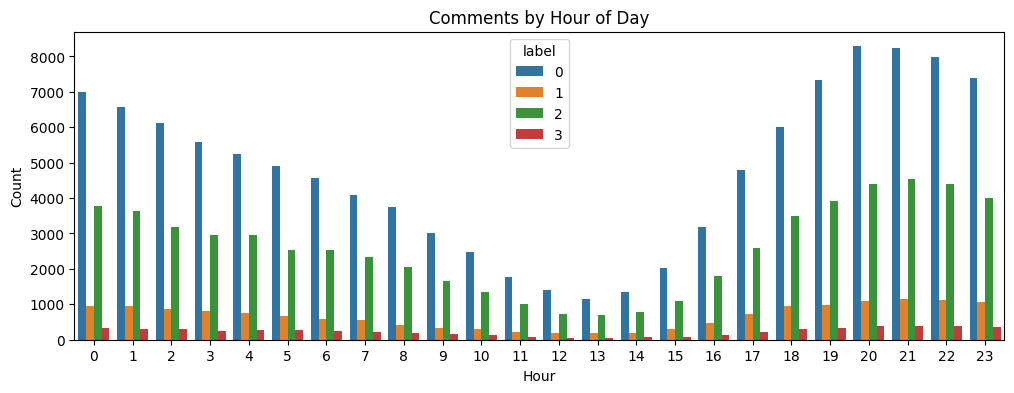

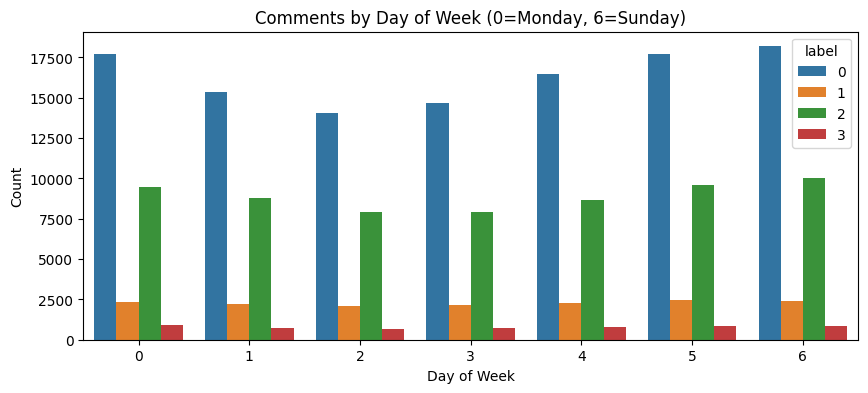

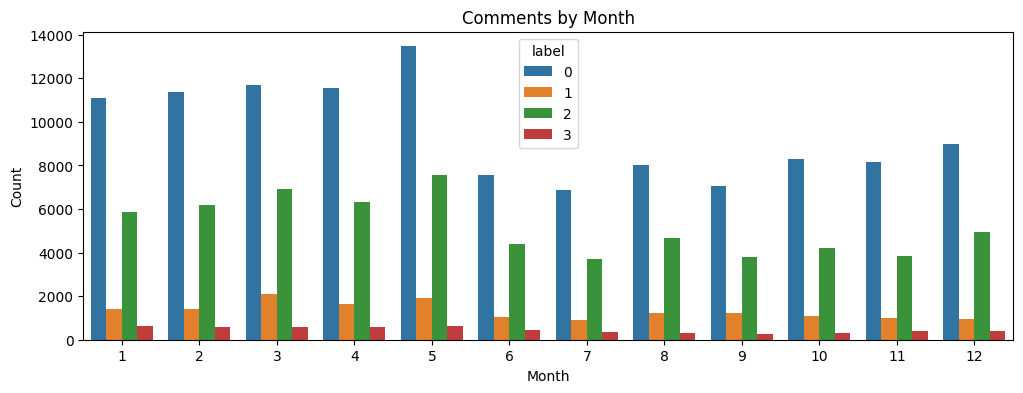

In [9]:
# Extract date features
train['created_date'] = pd.to_datetime(train['created_date'], utc=True)
train['hour']       = train['created_date'].dt.hour
train['month']      = train['created_date'].dt.month
train['dayofweek']  = train['created_date'].dt.dayofweek
train['year']       = train['created_date'].dt.year

# Hour vs label
plt.figure(figsize=(12,4))
sns.countplot(x='hour', hue='label', data=train, palette='tab10')
plt.title('Comments by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

# Day of week vs label
plt.figure(figsize=(10,4))
sns.countplot(x='dayofweek', hue='label', data=train, palette='tab10')
plt.title('Comments by Day of Week (0=Monday, 6=Sunday)')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

# Month vs label
plt.figure(figsize=(12,4))
sns.countplot(x='month', hue='label', data=train, palette='tab10')
plt.title('Comments by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

## 2.8 - Correlation Analysis

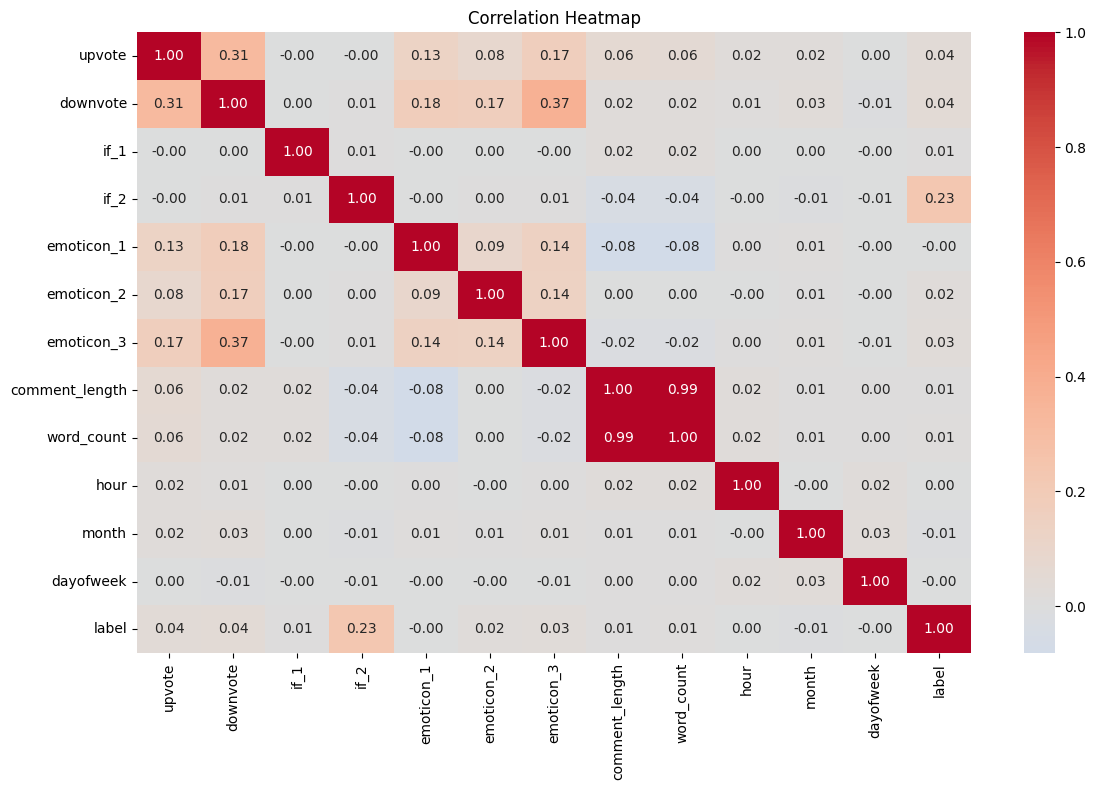

Features most correlated with label:
if_2              0.232902
downvote          0.044908
upvote            0.040181
emoticon_3        0.027273
emoticon_2        0.021597
month             0.013286
word_count        0.011709
comment_length    0.009371
if_1              0.007543
emoticon_1        0.003218
dayofweek         0.002236
hour              0.000868
Name: label, dtype: float64


In [10]:
# Correlation heatmap
corr_cols = ['upvote', 'downvote', 'if_1', 'if_2', 
             'emoticon_1', 'emoticon_2', 'emoticon_3',
             'comment_length', 'word_count', 'hour', 
             'month', 'dayofweek', 'label']

plt.figure(figsize=(12,8))
sns.heatmap(train[corr_cols].corr(), 
            annot=True, fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Top features correlated with label
print("Features most correlated with label:")
corr_with_label = train[corr_cols].corr()['label'].drop('label')
print(corr_with_label.abs().sort_values(ascending=False))

# 3. Data Preprocessing

## 3.1 - Fill Missing Values

In [11]:
# Fill comment
train['comment'] = train['comment'].fillna('')
test['comment']  = test['comment'].fillna('')

# Fill race, religion, gender with 'missing' as a new category
for col in ['race', 'religion', 'gender']:
    train[col] = train[col].fillna('missing')
    test[col]  = test[col].fillna('missing')

print("Missing values after filling:")
print(train.isnull().sum())
print("\nTest missing values after filling:")
print(test.isnull().sum())

Missing values after filling:
created_date      0
post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
race              0
religion          0
gender            0
disability        0
comment           0
label             0
comment_length    0
word_count        0
hour              0
month             0
dayofweek         0
year              0
dtype: int64

Test missing values after filling:
created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
dtype: int64


## 3.2 - Extract Date Features

In [12]:
train['created_date'] = pd.to_datetime(train['created_date'], utc=True)
test['created_date']  = pd.to_datetime(test['created_date'],  utc=True)

for df in [train, test]:
    df['hour']      = df['created_date'].dt.hour
    df['month']     = df['created_date'].dt.month
    df['dayofweek'] = df['created_date'].dt.dayofweek
    df['year']      = df['created_date'].dt.year
    df['quarter']   = df['created_date'].dt.quarter

print("Date features added:")
print(train[['hour', 'month', 'dayofweek', 'year', 'quarter']].head())

Date features added:
   hour  month  dayofweek  year  quarter
0     8      1          3  2024        1
1    21      3          6  2024        1
2    20      4          2  2024        2
3    22      5          6  2023        2
4    23      9          5  2023        3


## 3.3 - Extract Text Features

In [13]:
for df in [train, test]:
    df['comment_length']  = df['comment'].apply(len)
    df['word_count']      = df['comment'].apply(lambda x: len(x.split()))
    df['unique_words']    = df['comment'].apply(lambda x: len(set(x.split())))
    df['avg_word_length'] = df['comment'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
    df['uppercase_count'] = df['comment'].apply(
        lambda x: sum(1 for c in x if c.isupper()))
    df['exclamation']     = df['comment'].apply(lambda x: x.count('!'))
    df['question']        = df['comment'].apply(lambda x: x.count('?'))
    df['punctuation']     = df['comment'].apply(
        lambda x: sum(1 for c in x if c in '!?.,;:'))
    df['uppercase_ratio'] = df['uppercase_count'] / (df['comment_length'] + 1)
    df['lexical_diversity'] = df['unique_words'] / (df['word_count'] + 1)

print("Text features added:")
print(train[['comment_length', 'word_count', 'unique_words', 
             'avg_word_length', 'uppercase_count', 'exclamation',
             'question', 'punctuation', 'uppercase_ratio',
             'lexical_diversity']].head())

Text features added:
   comment_length  word_count  unique_words  avg_word_length  uppercase_count  \
0             118          20            19         4.950000                2   
1             644         110            74         4.854545                9   
2             751         133            97         4.654135               13   
3              91          15            15         5.133333                4   
4             254          40            37         5.375000                3   

   exclamation  question  punctuation  uppercase_ratio  lexical_diversity  
0            0         0            1         0.016807           0.904762  
1            0         0           10         0.013953           0.666667  
2            0         0           14         0.017287           0.723881  
3            0         0            4         0.043478           0.937500  
4            0         0           16         0.011765           0.902439  


## 3.4 - Handle Outliers

In [14]:
# Cap extreme values at 99th percentile

for col in ['upvote', 'downvote', 'if_1', 'if_2']:
    cap = train[col].quantile(0.99)
    train[col] = train[col].clip(upper=cap)
    test[col]  = test[col].clip(upper=cap)
    print(f"{col} capped at: {cap}")

upvote capped at: 22.0
downvote capped at: 9.0
if_1 capped at: 10.0
if_2 capped at: 66.0


##  3.5 - Encode Categorical Features

In [15]:
from sklearn.preprocessing import LabelEncoder

# Encode race, religion, gender
for col in ['race', 'religion', 'gender']:
    le = LabelEncoder()
    # fit on both train and test combined
    # so no unseen categories cause errors
    combined = pd.concat([train[col], test[col]])
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    print(f"{col} encoded. Unique values: {train[col].unique()}")

# Convert disability boolean to integer
train['disability'] = train['disability'].astype(int)
test['disability']  = test['disability'].astype(int)

print("\nEncoding done!")
print(train[['race', 'religion', 'gender', 'disability']].head())

race encoded. Unique values: [3 4 6 5 0 1 2]
religion encoded. Unique values: [5 2 6 7 4 0 8 3 1]
gender encoded. Unique values: [2 3 1 0 5 4]

Encoding done!
   race  religion  gender  disability
0     3         5       2           0
1     3         5       2           0
2     3         5       2           0
3     3         5       2           0
4     3         5       2           0


## 3.6 - Select Final Features

In [16]:
# Select all features for modeling
feature_cols = [
    # original numerical features
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 
    'if_1', 'if_2',
    # categorical encoded
    'race', 'religion', 'gender', 'disability',
    # text features
    'comment_length', 'word_count', 'unique_words',
    'avg_word_length', 'uppercase_count', 'exclamation',
    'question', 'punctuation', 'uppercase_ratio',
    'lexical_diversity',
    # date features
    'hour', 'month', 'dayofweek', 'year', 'quarter'
]

X = train[feature_cols]
y = train['label']
X_test_final = test[feature_cols]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Test shape:", X_test_final.shape)
print("\nFeature list:")
print(feature_cols)

Features shape: (198000, 26)
Target shape: (198000,)
Test shape: (102000, 26)

Feature list:
['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment_length', 'word_count', 'unique_words', 'avg_word_length', 'uppercase_count', 'exclamation', 'question', 'punctuation', 'uppercase_ratio', 'lexical_diversity', 'hour', 'month', 'dayofweek', 'year', 'quarter']


## 3.7 - Scale Features

In [17]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()
X_scaled       = scaler.fit_transform(X)
X_test_scaled  = scaler.transform(X_test_final)

# Convert back to dataframe for easier use
X_scaled      = pd.DataFrame(X_scaled,      columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Scaling done!")
print(X_scaled.describe().round(2))

Scaling done!
       emoticon_1  emoticon_2  emoticon_3     upvote   downvote       if_1  \
count   198000.00   198000.00   198000.00  198000.00  198000.00  198000.00   
mean        -0.00       -0.00       -0.00       0.00      -0.00      -0.00   
std          1.00        1.00        1.00       1.00       1.00       1.00   
min         -0.27       -0.19       -0.25      -0.63      -0.41      -0.54   
25%         -0.27       -0.19       -0.25      -0.63      -0.41      -0.54   
50%         -0.27       -0.19       -0.25      -0.37      -0.41      -0.54   
75%         -0.27       -0.19       -0.25       0.13       0.27       0.89   
max         45.66       42.37       35.09       4.95       5.69       3.03   

            if_2       race   religion     gender  ...  exclamation  \
count  198000.00  198000.00  198000.00  198000.00  ...    198000.00   
mean       -0.00       0.00       0.00       0.00  ...         0.00   
std         1.00       1.00       1.00       1.00  ...         1.00   

In [18]:
print(feature_cols)

['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment_length', 'word_count', 'unique_words', 'avg_word_length', 'uppercase_count', 'exclamation', 'question', 'punctuation', 'uppercase_ratio', 'lexical_diversity', 'hour', 'month', 'dayofweek', 'year', 'quarter']


In [19]:
print(X[feature_cols].nunique().sort_values())

disability               2
year                     3
quarter                  4
gender                   6
race                     7
dayofweek                7
if_1                     8
religion                 9
downvote                10
emoticon_2              10
month                   12
emoticon_3              16
upvote                  23
hour                    24
question                32
emoticon_1              36
exclamation             40
if_2                    48
punctuation             89
unique_words           154
word_count             212
uppercase_count        254
comment_length        1008
lexical_diversity     3339
avg_word_length      16233
uppercase_ratio      16439
dtype: int64


# 4. Feature Engineering

## 4.1 - Apply TF-IDF

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Apply TF-IDF on comment text
print("Fitting TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=9000,    # use top 9000 most important words
    ngram_range=(1, 1),   # single words
    min_df=2,             # ignore words appearing less than 2 times
    strip_accents='unicode',
    sublinear_tf=True     # reduces effect of very common words
)

X_tfidf_train = tfidf.fit_transform(train['comment'])
X_tfidf_test  = tfidf.transform(test['comment'])

print("TF-IDF train shape:", X_tfidf_train.shape)
print("TF-IDF test shape:",  X_tfidf_test.shape)

Fitting TF-IDF...
TF-IDF train shape: (198000, 9000)
TF-IDF test shape: (102000, 9000)


## 4.2 - Combine TF-IDF with Numerical Features

In [21]:
X_num_train = csr_matrix(X_scaled.values)
X_num_test  = csr_matrix(X_test_scaled.values)

X_combined_train = hstack([X_num_train, X_tfidf_train])
X_combined_test  = hstack([X_num_test,  X_tfidf_test])

print("Combined train shape:", X_combined_train.shape)
print("Combined test shape:",  X_combined_test.shape)

Combined train shape: (198000, 9026)
Combined test shape: (102000, 9026)


# 5. Train Validation Spliting

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_combined_train, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same label distribution in both splits
)

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:",   y_val.shape)

print("\nLabel distribution in y_train:")
print(y_train.value_counts(normalize=True).round(4)*100)
print("\nLabel distribution in y_val:")
print(y_val.value_counts(normalize=True).round(4)*100)

X_train shape: (158400, 9026)
X_val shape: (39600, 9026)
y_train shape: (158400,)
y_val shape: (39600,)

Label distribution in y_train:
label
0    57.66
2    31.54
1     8.04
3     2.76
Name: proportion, dtype: float64

Label distribution in y_val:
label
0    57.66
2    31.54
1     8.04
3     2.76
Name: proportion, dtype: float64


# 6. Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

## 6.1 - Logistic Regression

In [24]:
print("Training Logistic Regression...")
lr = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_f1 = f1_score(y_val, lr_preds, average='macro')
print(f"LR Macro F1: {lr_f1:.4f}")
print(classification_report(y_val, lr_preds))

Training Logistic Regression...
LR Macro F1: 0.7246
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.60      0.80      0.69      3183
           2       0.88      0.73      0.80     12488
           3       0.33      0.78      0.46      1094

    accuracy                           0.86     39600
   macro avg       0.69      0.81      0.72     39600
weighted avg       0.89      0.86      0.87     39600



## 6.2 - Linear SVM

In [25]:
print("\nTraining Linear SVM...")
svm = LinearSVC(
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_val)
svm_f1 = f1_score(y_val, svm_preds, average='macro')
print(f"SVM Macro F1: {svm_f1:.4f}")
print(classification_report(y_val, svm_preds))


Training Linear SVM...
SVM Macro F1: 0.7597
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     22835
           1       0.67      0.80      0.73      3183
           2       0.87      0.82      0.84     12488
           3       0.46      0.67      0.55      1094

    accuracy                           0.87     39600
   macro avg       0.73      0.80      0.76     39600
weighted avg       0.88      0.87      0.87     39600



## 6.3 - XGBoost

In [26]:
print("\nTraining XGBoost...")
xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_val)
xgb_f1 = f1_score(y_val, xgb_preds, average='macro')
print(f"XGB Macro F1: {xgb_f1:.4f}")
print(classification_report(y_val, xgb_preds))


Training XGBoost...
XGB Macro F1: 0.7882
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.74      0.76      3183
           2       0.84      0.92      0.88     12488
           3       0.74      0.44      0.55      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.76      0.79     39600
weighted avg       0.91      0.91      0.91     39600



Top 30 XGBoost Feature Importances:

if_2          0.051748
if_1          0.017112
kill          0.010405
shoot         0.010351
religion      0.008652
race          0.008529
lock          0.008047
white         0.007493
shot          0.007137
gay           0.006072
death         0.005831
die           0.005567
stupid        0.005394
liar          0.004768
pathetic      0.004631
dumb          0.004596
ridiculous    0.004569
ignorant      0.004528
immigrants    0.004185
clown         0.004178
fools         0.004035
silly         0.003964
loser         0.003931
fool          0.003873
hypocrite     0.003861
dead          0.003773
religion      0.003721
ignorance     0.003717
clowns        0.003681
garbage       0.003542
dtype: float32


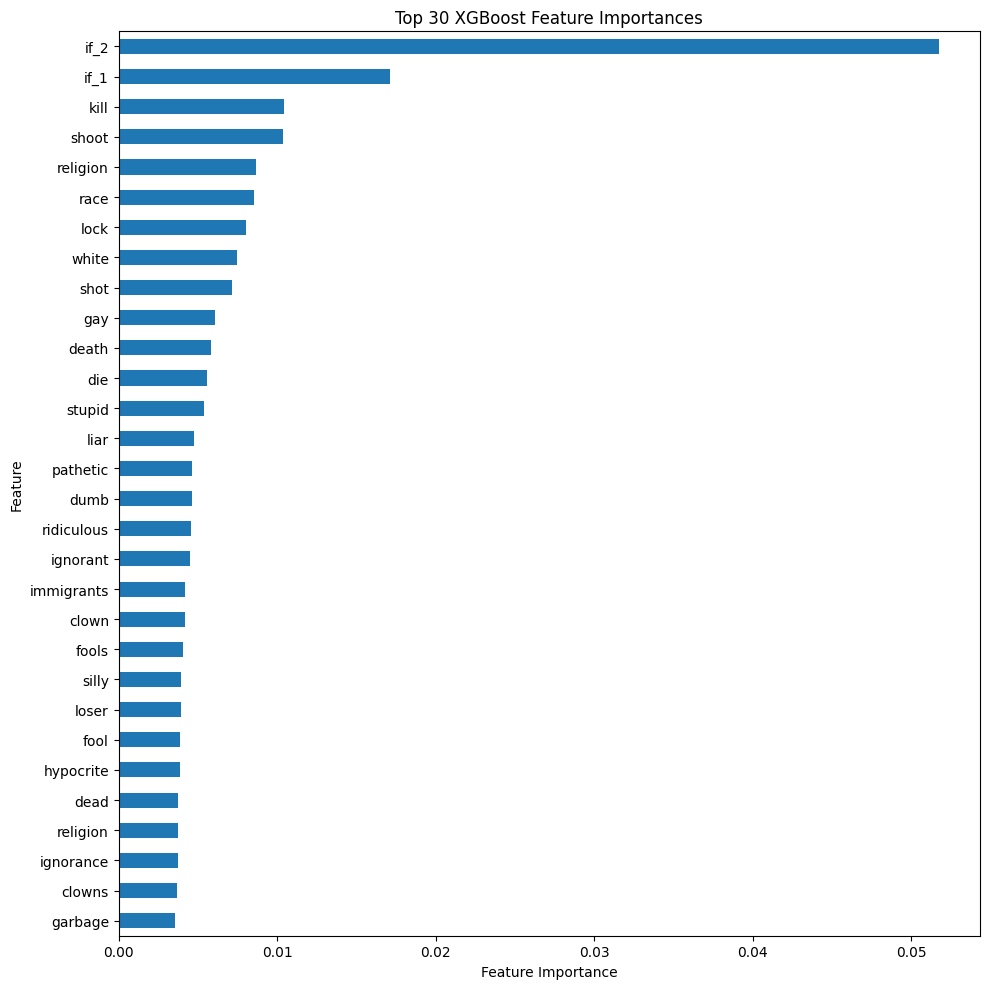

Top numerical features:
if_2               0.051748
if_1               0.017112
religion           0.008652
race               0.008529
religion           0.003721
disability         0.002687
race               0.001543
unique_words       0.001433
gender             0.001408
comment_length     0.001280
gender             0.001070
word_count         0.000861
avg_word_length    0.000634
uppercase_count    0.000503
emoticon_2         0.000440
year               0.000364
question           0.000334
downvote           0.000319
emoticon_1         0.000305
uppercase_ratio    0.000247
dtype: float32

Top text features:
kill          0.010405
shoot         0.010351
religion      0.008652
race          0.008529
lock          0.008047
white         0.007493
shot          0.007137
gay           0.006072
death         0.005831
die           0.005567
stupid        0.005394
liar          0.004768
pathetic      0.004631
dumb          0.004596
ridiculous    0.004569
ignorant      0.004528
immigrants   

In [27]:
feature_names = list(X_scaled.columns) + list(tfidf.get_feature_names_out())

importance = pd.Series(
    xgb.feature_importances_,
    index=feature_names
)

top_30 = importance.sort_values(ascending=False).head(30)

print("Top 30 XGBoost Feature Importances:\n")
print(top_30)

plt.figure(figsize=(10, 10))
top_30.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 30 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

numeric_importance = importance[X_scaled.columns]
text_importance = importance[tfidf.get_feature_names_out()]

print("Top numerical features:")
print(numeric_importance.sort_values(ascending=False).head(20))

print("\nTop text features:")
print(text_importance.sort_values(ascending=False).head(30))

## 6.4 - LightGBM

In [28]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective='multiclass',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

lgbm_preds = lgbm.predict(X_val)

lgbm_f1 = f1_score(
    y_val,
    lgbm_preds,
    average='macro'
)

print(f"LightGBM Macro F1: {lgbm_f1:.4f}")
print(classification_report(y_val, lgbm_preds))

LightGBM Macro F1: 0.8117
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.78      0.78      3183
           2       0.85      0.92      0.89     12488
           3       0.75      0.53      0.62      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.79      0.81     39600
weighted avg       0.92      0.92      0.92     39600



if_2                 873
avg_word_length      510
uppercase_ratio      409
white                322
lexical_diversity    292
comment_length       288
the                  269
stupid               262
if_1                 255
ridiculous           253
ignorant             251
kill                 247
is                   244
hour                 243
and                  223
black                219
you                  218
of                   216
silly                215
are                  210
to                   209
trump                206
uppercase_count      203
fool                 190
dumb                 188
pathetic             184
unique_words         174
race                 172
be                   171
that                 171
dtype: int32


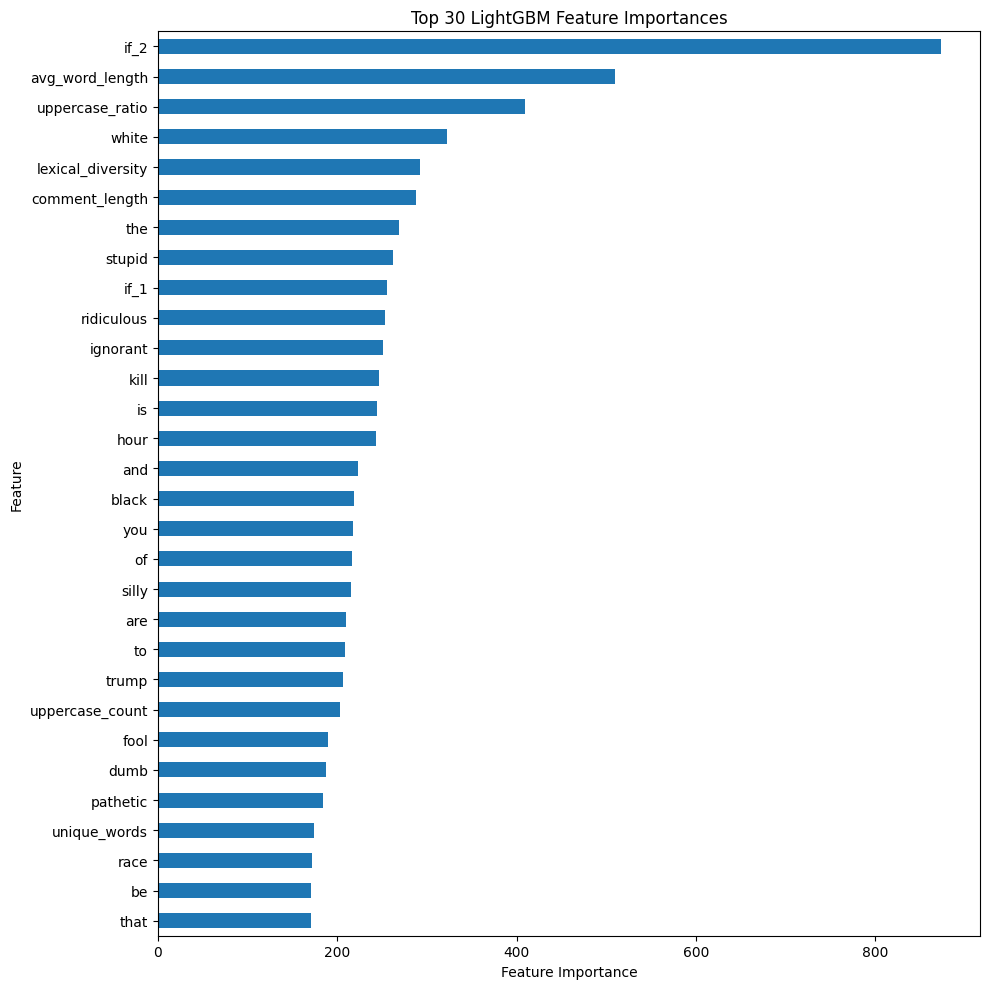

Top numerical features:
if_2                 873
avg_word_length      510
uppercase_ratio      409
lexical_diversity    292
comment_length       288
if_1                 255
hour                 243
uppercase_count      203
unique_words         174
race                 172
upvote               155
month                155
punctuation          145
religion             139
word_count           135
dayofweek            119
religion              88
downvote              70
gender                63
emoticon_1            58
dtype: int32

Top text features:
white         322
the           269
stupid        262
ridiculous    253
ignorant      251
kill          247
is            244
hour          243
and           223
black         219
you           218
of            216
silly         215
are           210
to            209
trump         206
fool          190
dumb          188
pathetic      184
race          172
be            171
that          171
racist        167
hypocrisy     166
shoot      

In [29]:
feature_names = list(X_scaled.columns) + list(tfidf.get_feature_names_out())

importance = pd.Series(
    lgbm.feature_importances_,
    index=feature_names
)

top_30 = importance.sort_values(ascending=False).head(30)

print(top_30)

plt.figure(figsize=(10, 10))
top_30.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 30 LightGBM Feature Importances")
plt.tight_layout()
plt.show()

numeric_importance = importance[X_scaled.columns]
text_importance = importance[tfidf.get_feature_names_out()]

print("Top numerical features:")
print(numeric_importance.sort_values(ascending=False).head(20))

print("\nTop text features:")
print(text_importance.sort_values(ascending=False).head(30))

## 6.5 - Ensemble (XGBoost + LightGBM)

In [30]:
xgb_proba = xgb.predict_proba(X_val)
lgbm_proba = lgbm.predict_proba(X_val)

ensemble_proba = 0.3 * xgb_proba + 0.7 * lgbm_proba

ensemble_preds = np.argmax(ensemble_proba, axis=1)

ensemble_f1 = f1_score(
    y_val,
    ensemble_preds,
    average='macro'
)

print("Ensemble Macro F1:", ensemble_f1)

Ensemble Macro F1: 0.8066353093677544


# 7. Model & Plot Comparission

In [31]:
print("\n--- Model Comparison (Macro F1) ---")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'XGBoost', 'LightGBM', 'Ensemble'],
    'Macro F1': [lr_f1, svm_f1, xgb_f1, lgbm_f1, ensemble_f1]
})
print(results.sort_values('Macro F1', ascending=False))


--- Model Comparison (Macro F1) ---
                 Model  Macro F1
3             LightGBM  0.811718
4             Ensemble  0.806635
2              XGBoost  0.788197
1           Linear SVM  0.759663
0  Logistic Regression  0.724605


# 8. Submission

In [32]:
best_model_name = results.loc[results['Macro F1'].idxmax(), 'Model']

if best_model_name == 'Ensemble':
    test_proba = 0.3 * xgb.predict_proba(X_combined_test) + 0.7 * lgbm.predict_proba(X_combined_test)
    test_predictions = np.argmax(test_proba, axis=1)
else:
    best_model = {
        'Logistic Regression': lr,
        'Linear SVM': svm,
        'XGBoost': xgb,
        'LightGBM': lgbm
    }[best_model_name]
    test_predictions = best_model.predict(X_combined_test)


print("Best Model:", best_model_name)

Best Model: LightGBM


In [33]:
sample_sub['label'] = test_predictions
sample_sub.to_csv('submission.csv', index=False)
print("Submission saved!")
print(sample_sub.head())
print("\nPrediction distribution:")
print(sample_sub['label'].value_counts())

Submission saved!
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2

Prediction distribution:
label
0    57014
2    35087
1     7997
3     1902
Name: count, dtype: int64
